In [21]:
!pip install python-dotenv
!pip install pandas

In [22]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [23]:
import requests
import pandas as pd

In [24]:
import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("Census_api")
print(API_KEY)

597db9222a018a9f22cc8614ce64cc30ee8598ab


In [25]:
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,B01001_001E&for=county:*&in=state:37&key={'API_KEY'}"

In [26]:
response = requests.get(url)

In [27]:
response

<Response [200]>

In [29]:
response.json()[:5]

[['NAME', 'B19101_017E', 'B01001_001E', 'state', 'county'],
 ['Alamance County, North Carolina', '4905', '183040', '37', '001'],
 ['Brunswick County, North Carolina', '4845', '167112', '37', '019'],
 ['Buncombe County, North Carolina', '10244', '279210', '37', '021'],
 ['Burke County, North Carolina', '2081', '88545', '37', '023']]

In [10]:
data = response.json()

In [11]:
data

[['NAME', 'B01001_001E', 'state', 'county'],
 ['Alamance County, North Carolina', '183040', '37', '001'],
 ['Brunswick County, North Carolina', '167112', '37', '019'],
 ['Buncombe County, North Carolina', '279210', '37', '021'],
 ['Burke County, North Carolina', '88545', '37', '023'],
 ['Cabarrus County, North Carolina', '244925', '37', '025'],
 ['Caldwell County, North Carolina', '80739', '37', '027'],
 ['Carteret County, North Carolina', '70259', '37', '031'],
 ['Catawba County, North Carolina', '167054', '37', '035'],
 ['Chatham County, North Carolina', '83874', '37', '037'],
 ['Cleveland County, North Carolina', '102194', '37', '045'],
 ['Craven County, North Carolina', '104167', '37', '049'],
 ['Cumberland County, North Carolina', '338430', '37', '051'],
 ['Davidson County, North Carolina', '177809', '37', '057'],
 ['Durham County, North Carolina', '343628', '37', '063'],
 ['Forsyth County, North Carolina', '398143', '37', '067'],
 ['Franklin County, North Carolina', '79771', '37'

In [12]:
df = pd.DataFrame(data[1:], columns=data[0])
df.head()

,NAME,B01001_001E,state,county
0,"Alamance County, North Carolina",183040,37,001
1,"Brunswick County, North Carolina",167112,37,019
2,"Buncombe County, North Carolina",279210,37,021
3,"Burke County, North Carolina",88545,37,023
4,"Cabarrus County, North Carolina",244925,37,025


In [28]:
variables = ",".join([
    "NAME",            # County name
    "B19101_017E",     # Family income $200,000 or more
    "B01001_001E",     # Population
])

url = f"https://api.census.gov/data/2024/acs/acs1?get={variables}&for=county:*&in=state:37&key={API_KEY}"

response = requests.get(url)

data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

df.head()

,NAME,B19101_017E,B01001_001E,state,county
0,"Alamance County, North Carolina",4905,183040,37,001
1,"Brunswick County, North Carolina",4845,167112,37,019
2,"Buncombe County, North Carolina",10244,279210,37,021
3,"Burke County, North Carolina",2081,88545,37,023
4,"Cabarrus County, North Carolina",12169,244925,37,025


In [30]:
df.to_csv("census_data.csv", index=False)

In [31]:
df.dtypes

NAME           str
B19101_017E    str
B01001_001E    str
state          str
county         str
dtype: object

In [4]:
import pandas as pd
df = pd.read_csv("census_data.csv")
print(df.head())

   B19101_017E  B01001_001E                              NAME  state  county
0         4905       183040   Alamance County, North Carolina     37       1
1         4845       167112  Brunswick County, North Carolina     37      19
2        10244       279210   Buncombe County, North Carolina     37      21
3         2081        88545      Burke County, North Carolina     37      23
4        12169       244925   Cabarrus County, North Carolina     37      25


In [5]:
df.dtypes

B19101_017E    int64
B01001_001E    int64
NAME             str
state          int64
county         int64
dtype: object

In [6]:
df.isnull().sum()

B19101_017E    0
B01001_001E    0
NAME           0
state          0
county         0
dtype: int64

In [17]:
import matplotlib.pyplot as plt

In [32]:
numeric_cols = [            # County name
        "B19101_017E",     # Family income $200,000 or more
        "B01001_001E",     # Population 
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") # coerce -> If something cannot be converted to a number, don’t crash. Instead, turn it into NaN.

df = df.rename(columns={
    "NAME": "County_Name",
    "B19101_017E": "High_Income_Families",
    "B01001_001E": "Total_Population"
})

df.head()

,County_Name,High_Income_Families,Total_Population,state,county
0,"Alamance County, North Carolina",4905,183040,37,001
1,"Brunswick County, North Carolina",4845,167112,37,019
2,"Buncombe County, North Carolina",10244,279210,37,021
3,"Burke County, North Carolina",2081,88545,37,023
4,"Cabarrus County, North Carolina",12169,244925,37,025


In [33]:
df.dtypes

County_Name               str
High_Income_Families    int64
Total_Population        int64
state                     str
county                    str
dtype: object

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

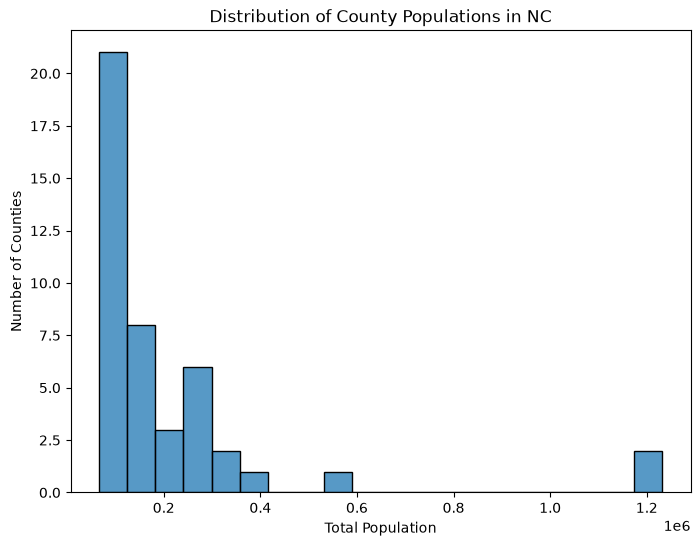

In [38]:
plt.figure(figsize=(8,6))
sns.histplot(df["Total_Population"], bins=20)
plt.title("Distribution of County Populations in NC")
plt.xlabel("Total Population")
plt.ylabel("Number of Counties")
plt.show()

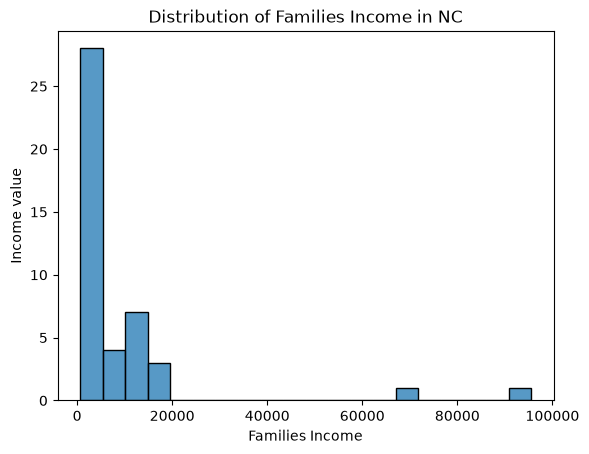

In [39]:
sns.histplot(data=df, x="High_Income_Families", bins=20)
plt.title("Distribution of Families Income in NC")
plt.xlabel("Families Income")
plt.ylabel("Income value")
plt.show()